# Distributed Lightweight SUMMA Runner (Manual Tweaks)

This notebook mirrors the lumped lightweight workflow style for distributed runs.

## What it does
- Runs quick scenario loops against an already-prepared distributed project
- Applies manual model-decision and parameter tweaks in an isolated settings sandbox
- Lets you focus on timing/magnitude tuning (routing delay, melt timing, runoff partitioning)
- Writes each scenario output to a separate lightweight run folder

## Recommended use
1. Keep domain + forcing prep outside this notebook (run once with the distributed workflow runner).
2. Use this notebook for fast reruns of `run_models` with manual tweaks.
3. Start with one-at-a-time sweeps, then tighten around best candidates.

In [1]:
import os
import sys
import shutil
import signal
import subprocess
import time
from pathlib import Path
from itertools import product
from datetime import datetime

import numpy as np
import pandas as pd
import xarray as xr
import yaml
import matplotlib.pyplot as plt

os.chdir('/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro')
repo_root = Path.cwd()

from CONFLUENCE import CONFLUENCE
from utils.custom.adjust_settings import edit_modelDecisions, update_and_reformat_parameter_file, _format_parameter_value
from utils.custom import calc

plt.style.use('default')
%matplotlib inline
print(f'Repo root: {repo_root}')

Repo root: /home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro


## Configure Manual Tuning

Use these settings exactly like the lumped notebook style:

- `CONFIG_PATH`: distributed config to run
- `DECISION_SWEEP`: process decisions to test
- `LOCAL_PARAM_DEFAULTS` and `BASIN_PARAM_DEFAULTS`: manual parameter tweaks
- `SWEEP_MODE='one_at_a_time'` for targeted diagnosis
- `USE_FILTERED_FORCING_FOR_RUN=True` keeps run-local forcing deterministic

In [40]:
# ---------------------------------------------------------------------
# USER SETTINGS
# ---------------------------------------------------------------------
CONFIG_PATH = repo_root / 'ess-project' / '0_config_files' / 'config_Tuolumne_River_distributed_elevAspect.yaml'

SIM_START = '2015-10-01 00:00'
SIM_END = '2019-09-30 23:00'
EVAL_START = '2016-10-01'
EVAL_END = '2019-09-30'
SPINUP_PERIOD = '2015-10-01, 2016-09-30'

RUN_TAG = datetime.now().strftime('%Y%m%d_%H%M%S')
BASE_SCENARIO_NAME = 'base'

MAX_PREVIOUS_RUN_CORES = 1
FORCE_SERIAL_SUMMA_FOR_DIAGNOSTICS = True
AUTO_TERMINATE_STALE_MODEL_PROCESSES = True
MAX_TERMINATE_WAIT_SECONDS = 10
THREAD_ENV_VARS = ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS', 'NUMEXPR_NUM_THREADS')
for _env_name in THREAD_ENV_VARS:
    os.environ[_env_name] = '1'

CONFIG_UPDATES = {
    'EXPERIMENT_TIME_START': SIM_START,
    'EXPERIMENT_TIME_END': SIM_END,
    'EVALUATION_PERIOD': f'{EVAL_START}, {EVAL_END}',
    'SPINUP_PERIOD': SPINUP_PERIOD,
    'FORCING_DATASET': 'METSIM',
    'FORCING_PRODUCT_TAG': 'metsim',
    'SETTINGS_SUMMA_USE_PARALLEL_SUMMA': not FORCE_SERIAL_SUMMA_FOR_DIAGNOSTICS,
    'SETTINGS_SUMMA_CONNECT_HRUS': True,
    'SETTINGS_SUMMA_TRIALPARAMS': 'trialParams.nc',
    'USE_LINEAR_RESERVOIR_ROUTING': True,
    'LINEAR_RESERVOIR_K_FAST_DEFAULT': 0.4,
    'LINEAR_RESERVOIR_K_SLOW_DEFAULT': 0.0038,
    'LINEAR_RESERVOIR_F_FAST_DEFAULT': 0.9,
}


FORCING_SOURCE_DIR_OVERRIDE = '/scratch/dlhogan/ess-project-data/domain_Tuolumne_River_distributed_elevAspect/forcing/SUMMA_input'
USE_FILTERED_FORCING_FOR_RUN = True
FORCING_PRODUCT_TAG_OVERRIDE = 'metsim'

USE_ISOLATED_SETTINGS_SANDBOX = True

INIT_CONDITION_FILE = 'coldState.nc'
SOURCE_TRIAL_PARAMS_NAME = None
# Set to path of an elevation-only trialParams.nc to seed the elevAspect file from it
# (each elevation band's values are repeated for ASPECTS_PER_BAND aspect classes).
# Leave None to use the existing elevAspect trialParams.nc as-is.
SEED_FROM_ELEV_ONLY_NC = None
ASPECTS_PER_BAND = 5
ACTIVE_TRIAL_PARAMS_NAME = 'trialParams.nc'
EXPECTED_HRU_COUNT = 26
RUNOFF_EVAL_VAR = 'basin__TotalRunoff'  # 'averageRoutedRunoff' or 'scalarTotalRunoff'

DECISION_SWEEP = {
    'groundwatr': ['qTopmodl'],
    'hc_profile': ['pow_prof'],
    'bcLowrSoiH': ['zeroFlux'],
    'stomResist': ['Jarvis'],
    'subRouting': ['timeDlay'],
    'alb_method': ['varDecay'],
}

SWEEP_MODE = 'one_at_a_time'
USE_FIRST_VALUE_AS_BASELINE = True

# Keep text-file updates on for parameters not represented in trialParams files.
APPLY_TXT_PARAMETER_UPDATES = True

LOCAL_PARAM_DEFAULTS = {
    'albedoMinVisible': 0.50,
}
aspects_per_band = [1, 5, 5, 5, 5, 3, 1, 1]  # bands 0→7 (3681m → 1396m), 26 total

def expand_per_band(per_band, n_per_band):
    return np.array(sum([[v] * n for v, n in zip(per_band, n_per_band)], []))

PRECIP_MULTIPLIER = np.array([1.5, 1.5, 1.9, 1.9, 2.3, 2.3, 1.7, 1.7])
LW_MULTIPLIER     = np.array([1.3, 1.3, 1.3, 1.3, 1.15, 1.0, 1.0, 1.0])
TEMP_OFFSET_K     = np.array([0.0, 0.0, 0.0, 0.0, 0.0,  0.0,  0.0,  0.0])

PRECIP_MULTIPLIER_HRU = expand_per_band(PRECIP_MULTIPLIER, aspects_per_band)
LW_MULTIPLIER_HRU     = expand_per_band(LW_MULTIPLIER,     aspects_per_band)
TEMP_OFFSET_K_HRU     = expand_per_band(TEMP_OFFSET_K,     aspects_per_band)

# Replace METSIM LWRadAtm with Dilley & O'Brien (1998) empirical estimate
# before applying LW_MULTIPLIER.  Set False to keep METSIM LW as-is.
APPLY_LW_DILLEY_OBRIEN = True

trial_parms_file = xr.open_dataset("/scratch/dlhogan/ess-project-data/domain_Tuolumne_River_distributed_elevAspect/settings/SUMMA/trialParams.nc")
TRIAL_PARAM_VALS = {
    # 'albedoDecayRate': expand_per_band([1.19e5]*8, aspects_per_band),
    # 'frozenPrecipMultip': list(trial_parms_file['frozenPrecipMultip'].values*1.9),
}
# Basin parameters can exist in trialParams at GRU dimension.
BASIN_PARAM_DEFAULTS = {
    'routingGammaShape': 1.5,
    'routingGammaScale': 76000,
}

# Parameters written into trialParams*.nc (HRU + GRU parameters).
TRIAL_PARAM_UPDATES = {
    **TRIAL_PARAM_VALS,
    # **BASIN_PARAM_DEFAULTS,
}

STREAMFLOW_CSV_NAME = 'streamflow_obs.csv'

print('Config:', CONFIG_PATH)
print('Decision sweep keys:', list(DECISION_SWEEP.keys()))
print('Sweep mode:', SWEEP_MODE)
print('Isolated settings sandbox:', USE_ISOLATED_SETTINGS_SANDBOX)
print('Apply txt parameter updates:', APPLY_TXT_PARAMETER_UPDATES)
print('Trial params source:', SOURCE_TRIAL_PARAMS_NAME)
print('Trial params active:', ACTIVE_TRIAL_PARAMS_NAME)
print('Expected HRU count:', EXPECTED_HRU_COUNT)
print('Apply LW Dilley-O\'Brien correction:', APPLY_LW_DILLEY_OBRIEN)
print('Force serial SUMMA for diagnostics:', FORCE_SERIAL_SUMMA_FOR_DIAGNOSTICS)
print('Auto-terminate stale model processes:', AUTO_TERMINATE_STALE_MODEL_PROCESSES)
print('Thread caps:', {k: os.environ.get(k) for k in THREAD_ENV_VARS})
print('trialParams updates:', TRIAL_PARAM_UPDATES)

Config: /home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/0_config_files/config_Tuolumne_River_distributed_elevAspect.yaml
Decision sweep keys: ['groundwatr', 'hc_profile', 'bcLowrSoiH', 'stomResist', 'subRouting', 'alb_method']
Sweep mode: one_at_a_time
Isolated settings sandbox: True
Apply txt parameter updates: True
Trial params source: None
Trial params active: trialParams.nc
Expected HRU count: 26
Apply LW Dilley-O'Brien correction: True
Force serial SUMMA for diagnostics: True
Auto-terminate stale model processes: True
Thread caps: {'OMP_NUM_THREADS': '1', 'OPENBLAS_NUM_THREADS': '1', 'MKL_NUM_THREADS': '1', 'NUMEXPR_NUM_THREADS': '1'}
trialParams updates: {}


In [27]:
# ---------------------------------------------------------------------
# HELPERS: config, settings edits, forcing subsets, scenario definitions
# ---------------------------------------------------------------------
def load_config(path: Path) -> dict:
    with open(path, 'r') as f:
        return yaml.safe_load(f)


def project_paths(cfg: dict):
    data_dir = Path(cfg['CONFLUENCE_DATA_DIR'])
    domain_name = cfg['DOMAIN_NAME']
    project_dir = data_dir / f'domain_{domain_name}'
    settings_dir = project_dir / 'settings' / 'SUMMA'
    return project_dir, settings_dir


def find_active_model_processes() -> list:
    user = os.environ.get('USER', '').strip()
    if not user:
        return []

    cmd = ['ps', '-u', user, '-o', 'pid=,ppid=,stat=,etime=,cmd=']
    out = subprocess.run(cmd, check=True, capture_output=True, text=True).stdout

    include_tokens = (
        'summa',
        'route_runoff',
        'mizuroute',
        'ostrich',
        'confluence',
        'seasonal_ensemble',
        'lightweight_model_runner',
    )
    exclude_tokens = ('ipykernel', 'jupyter')

    rows = []
    for raw in out.splitlines():
        line = raw.strip()
        if not line:
            continue
        parts = line.split(None, 4)
        if len(parts) < 5:
            continue
        pid_s, ppid_s, stat, etime, cmdline = parts
        cmd_l = cmdline.lower()
        if any(tok in cmd_l for tok in include_tokens) and not any(tok in cmd_l for tok in exclude_tokens):
            rows.append({
                'pid': int(pid_s),
                'ppid': int(ppid_s),
                'stat': stat,
                'etime': etime,
                'cmd': cmdline,
            })
    return rows


def terminate_model_processes(process_rows: list, wait_seconds: int = 10):
    if not process_rows:
        return

    pids = sorted({int(row['pid']) for row in process_rows})
    for pid in pids:
        try:
            os.kill(pid, signal.SIGTERM)
        except ProcessLookupError:
            continue

    deadline = time.time() + max(1, int(wait_seconds))
    while time.time() < deadline:
        active = [r for r in find_active_model_processes() if int(r['pid']) in pids]
        if not active:
            return
        time.sleep(0.5)

    for pid in pids:
        try:
            os.kill(pid, signal.SIGKILL)
        except ProcessLookupError:
            continue

    still_active = [r for r in find_active_model_processes() if int(r['pid']) in pids]
    if still_active:
        raise RuntimeError(f'Could not terminate all stale model processes: {still_active}')


def ensure_clean_model_runtime(auto_terminate: bool = True, wait_seconds: int = 10):
    active = find_active_model_processes()
    if not active:
        print('Model preflight: no stale SUMMA/mizuRoute/Ostrich/CONFLUENCE processes detected.')
        return

    print('Model preflight: stale model processes detected:')
    for row in active:
        print(f"  pid={row['pid']} stat={row['stat']} etime={row['etime']} cmd={row['cmd']}")

    if not auto_terminate:
        raise RuntimeError('Stale model processes are active. Set AUTO_TERMINATE_STALE_MODEL_PROCESSES=True or stop them manually.')

    terminate_model_processes(active, wait_seconds=wait_seconds)
    print('Model preflight: stale model processes terminated.')


def _parse_parameter_file_values(file_path: Path) -> dict:
    values = {}
    with open(file_path, 'r') as f:
        for raw in f:
            line = raw.strip()
            if not line or line.startswith('!') or '|' not in raw:
                continue
            parts = raw.rstrip('\n').split('|')
            if len(parts) < 2:
                continue
            key = parts[0].strip()
            val_str = parts[1].strip().replace('d', 'e').replace('D', 'e')
            try:
                values[key] = float(val_str)
            except ValueError:
                continue
    return values


def _assert_and_report_parameter_updates(
    file_path: Path,
    updates: dict,
    label: str,
    rel_tol: float = 1e-6,
    abs_tol: float = 1e-12,
):
    current = _parse_parameter_file_values(file_path)
    missing = [k for k in updates if k not in current]
    if missing:
        raise KeyError(f'{label}: parameters not found in {file_path.name}: {missing}')

    mismatched = []
    for k, expected in updates.items():
        expected_f = float(expected)
        actual_f = float(current[k])
        if not np.isclose(actual_f, expected_f, rtol=rel_tol, atol=abs_tol):
            mismatched.append((k, actual_f, expected_f))

    if mismatched:
        msg = ', '.join([f"{k}: actual={a:.6g}, expected={e:.6g}" for k, a, e in mismatched])
        raise RuntimeError(f'{label}: parameter verification failed after update: {msg}')

    applied_preview = {k: current[k] for k in updates}
    print(f'{label}: applied {len(applied_preview)} parameters -> {applied_preview}')


def _apply_updates_with_fallback(file_path: Path, updates: dict, strict: bool = True) -> int:
    if not updates:
        return 0

    res = update_and_reformat_parameter_file(file_path, updates, reformat_all=True, verbose=False)
    updated_count = int(res.get('updated_count', 0)) if isinstance(res, dict) else 0
    if updated_count == len(updates):
        if strict:
            _assert_and_report_parameter_updates(file_path, updates, label=file_path.name)
        return updated_count

    with open(file_path, 'r') as f:
        lines = f.readlines()

    new_lines = []
    n = 0
    for line in lines:
        stripped = line.strip()
        if not stripped or stripped.startswith('!') or '|' not in line:
            new_lines.append(line)
            continue

        parts = line.rstrip('\n').split('|')
        if len(parts) < 4:
            new_lines.append(line)
            continue

        key = parts[0].strip()
        if key in updates:
            parts[1] = f" {_format_parameter_value(updates[key])} "
            line = '|'.join(parts) + '\n'
            n += 1

        new_lines.append(line)

    if n > 0:
        with open(file_path, 'w') as f:
            f.writelines(new_lines)

    if strict:
        _assert_and_report_parameter_updates(file_path, updates, label=file_path.name)

    return n


def update_trial_params_nc(nc_path: Path, updates: dict) -> list:
    if not nc_path.exists():
        print(f'trialParams.nc not found at {nc_path}, skipping')
        return []

    with xr.open_dataset(nc_path) as ds_in:
        ds = ds_in.load()

    updated = []
    for name, value in updates.items():
        if name in ds.data_vars:
            ds[name].values[...] = float(value)
            updated.append(name)

    if updated:
        ds.to_netcdf(nc_path)
        print(f'trialParams.nc: updated {updated}')
    ds.close()
    return updated


def _replace_line_value(line: str, key: str, value: str):
    if not line.strip().startswith(key):
        return line, False
    if "'" not in line:
        return f"{key:<20} '{value}'\n", True
    left = line[: line.find("'")]
    right = line[line.rfind("'") + 1 :]
    return f"{left}'{value}'{right}", True


def update_file_manager_for_run(
    file_manager: Path,
    sim_id: str,
    out_dir: Path,
    sim_start: str,
    sim_end: str,
    settings_path: Path = None,
    forcing_path: Path = None,
    init_condition_file: str = None,
):
    with open(file_manager, 'r') as f:
        lines = f.readlines()

    replacements = {
        'simStartTime': sim_start,
        'simEndTime': sim_end,
        'outFilePrefix': sim_id,
        'outputPath': str(out_dir) + '/',
    }
    if settings_path is not None:
        replacements['settingsPath'] = str(settings_path) + '/'
    if forcing_path is not None:
        replacements['forcingPath'] = str(forcing_path) + '/'
    if init_condition_file is not None:
        replacements['initConditionFile'] = init_condition_file

    new_lines = []
    seen = {k: False for k in replacements}

    for line in lines:
        updated = line
        for key, value in replacements.items():
            updated, changed = _replace_line_value(updated, key, value)
            if changed:
                seen[key] = True
                break
        new_lines.append(updated)

    missing = [k for k, found in seen.items() if not found]
    if missing:
        raise RuntimeError(f'Missing required keys in fileManager.txt: {missing}')

    with open(file_manager, 'w') as f:
        f.writelines(new_lines)


def _months_between(start_ts: pd.Timestamp, end_ts: pd.Timestamp):
    months = []
    cur = pd.Timestamp(start_ts.year, start_ts.month, 1)
    end_m = pd.Timestamp(end_ts.year, end_ts.month, 1)
    while cur <= end_m:
        months.append(cur.strftime('%Y%m'))
        cur = cur + pd.offsets.MonthBegin(1)
    return set(months)


def _extract_yyyymm_from_name(name: str):
    stem = Path(name).stem
    token = stem.split('_')[-1]
    return token if len(token) == 6 and token.isdigit() else None


def _matches_forcing_tag(name: str, tag: str | None) -> bool:
    if tag is None:
        return True
    tag_text = str(tag).strip().lower()
    if tag_text == '':
        return True
    name_l = name.lower()
    if tag_text == 'era5':
        return ('era5' in name_l) and ('metsim' not in name_l)
    return tag_text in name_l


def prepare_forcing_subset(
    source_forcing_dir: Path,
    target_forcing_dir: Path,
    target_forcing_list: Path,
    sim_start: str,
    sim_end: str,
    product_tag: str | None = None,
):
    target_forcing_dir.mkdir(parents=True, exist_ok=True)

    keep_months = _months_between(pd.Timestamp(sim_start), pd.Timestamp(sim_end))
    all_nc = sorted(source_forcing_dir.glob('*.nc'))
    selected = []
    for fp in all_nc:
        yyyymm = _extract_yyyymm_from_name(fp.name)
        if yyyymm is None or yyyymm not in keep_months:
            continue
        if not _matches_forcing_tag(fp.name, product_tag):
            continue
        selected.append(fp)

    if not selected:
        raise RuntimeError(
            f'No forcing files selected from {source_forcing_dir} for months {sorted(keep_months)} '
            f'with tag={product_tag!r}'
        )

    for src_file in selected:
        shutil.copy2(src_file, target_forcing_dir / src_file.name)

    with open(target_forcing_list, 'w') as f:
        for fp in selected:
            f.write(f'{fp.name}\n')

    print(f'Prepared {len(selected)} forcing files from {source_forcing_dir}')
    print(f'  Product tag: {product_tag!r}')
    print(f'  First/last: {selected[0].name} ... {selected[-1].name}')
    return [fp.name for fp in selected]


def apply_forcing_perturbations(
    forcing_dir: Path,
    precip_multiplier,
    temp_offset_k,
    lw_multiplier=1.0,
    recalc_lw_dilley_obrien: bool = False,
) -> None:
    """Apply per-HRU precip scaling, temperature offset, and LW multiplier in-place.

    If recalc_lw_dilley_obrien=True, LWRadAtm is first replaced by the Dilley &
    O'Brien (1998) empirical estimate from airtemp/airpres/spechum, then any
    lw_multiplier is applied on top.  This corrects METSIM LW independently of
    any temperature offset.

    Intended for use on filtered forcing copies only — never call on source files.
    """
    def _to_arr(v):
        a = np.atleast_1d(np.asarray(v, dtype=np.float32))
        return a  # shape (1,) or (n_hru,)

    def _all_close(v, target):
        return bool(np.all(np.isclose(np.asarray(v, dtype=float), target)))

    def _hru_da(arr, ds):
        hru_dim = 'hru' if 'hru' in ds.dims else list(ds.dims)[-1]
        n = ds.sizes[hru_dim]
        a = np.broadcast_to(arr, (n,)).astype(np.float32)
        return xr.DataArray(a, dims=[hru_dim])

    apply_ppt  = not _all_close(precip_multiplier, 1.0)
    apply_temp = not _all_close(temp_offset_k, 0.0)
    apply_lw   = not _all_close(lw_multiplier,  1.0)

    if not apply_ppt and not apply_temp and not apply_lw and not recalc_lw_dilley_obrien:
        print('Forcing perturbations: none applied (all multipliers at identity, no LW recalculation)')
        return

    ppt_arr  = _to_arr(precip_multiplier)
    temp_arr = _to_arr(temp_offset_k)
    lw_arr   = _to_arr(lw_multiplier)

    nc_files = sorted(forcing_dir.glob('*.nc'))
    if not nc_files:
        print(f'WARNING: apply_forcing_perturbations — no netCDF files found in {forcing_dir}')
        return

    for fp in nc_files:
        with xr.open_dataset(fp) as ds:
            data = ds.load()
        if apply_ppt and 'pptrate' in data:
            data['pptrate'] = (data['pptrate'] * _hru_da(ppt_arr, data)).clip(min=0.0)
        if apply_temp and 'airtemp' in data:
            data['airtemp'] = data['airtemp'] + _hru_da(temp_arr, data)
        if recalc_lw_dilley_obrien and 'LWRadAtm' in data:
            data['LWRadAtm'] = calc.empirical_lw_dilley_obrien(data['airtemp'], data['airpres'], data['spechum'])
        if apply_lw and 'LWRadAtm' in data:
            data['LWRadAtm'] = (data['LWRadAtm'] * _hru_da(lw_arr, data)).clip(min=0.0)
        data.to_netcdf(fp)

    print(f'Forcing perturbations applied to {len(nc_files)} files')
    if recalc_lw_dilley_obrien:
        print('  LW recalculated via Dilley & O\'Brien (1998)')
    print(f'  precip×{np.asarray(precip_multiplier).tolist()}')
    print(f'  LW×   {np.asarray(lw_multiplier).tolist()}')
    print(f'  temp+ {np.asarray(temp_offset_k).tolist()} K')


def build_scenarios(decision_sweep: dict, mode: str = 'one_at_a_time', use_first_as_baseline: bool = True):
    scenarios = []

    if mode not in {'one_at_a_time', 'full_factorial'}:
        raise ValueError('mode must be one_at_a_time or full_factorial')

    baseline_decisions = {k: v[0] for k, v in decision_sweep.items() if v} if use_first_as_baseline else {}
    scenarios.append({'name': BASE_SCENARIO_NAME, 'decisions': baseline_decisions.copy()})

    if mode == 'one_at_a_time':
        for decision, values in decision_sweep.items():
            for i, value in enumerate(values):
                if use_first_as_baseline and i == 0:
                    continue
                trial = baseline_decisions.copy()
                trial[decision] = value
                scenarios.append({'name': f'{decision}__{value}', 'decisions': trial})
    else:
        keys = list(decision_sweep.keys())
        for combo in product(*[decision_sweep[k] for k in keys]):
            decisions = dict(zip(keys, combo))
            if decisions == baseline_decisions:
                continue
            label = '__'.join([f'{k}-{v}' for k, v in decisions.items()])
            scenarios.append({'name': label, 'decisions': decisions})

    return scenarios

In [28]:
# trialParams-focused parameter updater for distributed HRU/GRU tuning
def update_trial_params_nc(
    nc_path: Path,
    updates: dict,
    strict: bool = True,
    create_missing: bool = False,
    dims_override: dict | None = None,
    default_dim: str = 'hru',
    expected_hru_count: int | None = None,
) -> list:
    if not nc_path.exists():
        raise FileNotFoundError(f'trialParams file not found at {nc_path}')

    with xr.open_dataset(nc_path) as ds_in:
        ds = ds_in.load()

    if 'hru' not in ds.dims and 'gru' not in ds.dims:
        raise ValueError(f"trialParams file {nc_path} is missing both 'hru' and 'gru' dimensions")

    if expected_hru_count is not None and 'hru' in ds.dims:
        actual_hru_count = int(ds.sizes['hru'])
        if actual_hru_count != int(expected_hru_count):
            raise ValueError(
                f"Unexpected HRU size in {nc_path.name}: expected {expected_hru_count}, got {actual_hru_count}"
            )

    dims_override = dims_override or {}
    updated = []
    missing = []

    def _assign_vector_to_dim(target: xr.DataArray, arr: np.ndarray, dim_name: str):
        if dim_name not in target.dims:
            raise ValueError(f"{target.name}: dimension {dim_name} not present in target dims {target.dims}")
        expected_n = target.sizes[dim_name]
        if arr.size != expected_n:
            raise ValueError(
                f"Cannot assign {target.name}: vector length {arr.size} does not match {dim_name} size {expected_n}"
            )
        dim_index = target.dims.index(dim_name)
        shape = [1] * target.ndim
        shape[dim_index] = expected_n
        target.values[...] = arr.astype(target.dtype, copy=False).reshape(shape)

    for name, value in updates.items():
        if name not in ds.data_vars:
            if create_missing:
                arr = np.asarray(value, dtype=np.float64)
                dim = dims_override.get(name, default_dim)
                n = ds.sizes.get(dim)
                if n is None:
                    raise ValueError(f"Cannot create {name}: dimension '{dim}' not found in dataset")
                if arr.ndim == 0:
                    arr = np.full(n, float(arr))
                if arr.size != n:
                    raise ValueError(f"Cannot create {name}: value length {arr.size} != {dim} size {n}")
                ds[name] = xr.DataArray(arr, dims=[dim])
                updated.append(name)
                print(f'  Created new variable: {name} = {list(arr)}')
                continue
            missing.append(name)
            continue

        target = ds[name]
        arr = np.asarray(value)

        # Scalar value -> broadcast to full variable shape.
        if arr.ndim == 0:
            target.values[...] = float(arr)
            updated.append(name)
            continue

        # Exact shape provided -> assign directly.
        if tuple(arr.shape) == tuple(target.shape):
            target.values[...] = arr.astype(target.dtype, copy=False)
            updated.append(name)
            continue

        # 1D vector for variables with hru or gru dimension.
        if arr.ndim == 1 and ('hru' in target.dims or 'gru' in target.dims):
            if name in dims_override:
                chosen_dim = dims_override[name]
            elif target.ndim == 1:
                chosen_dim = target.dims[0]
            elif default_dim in target.dims:
                chosen_dim = default_dim
            elif 'hru' in target.dims:
                chosen_dim = 'hru'
            else:
                chosen_dim = 'gru'

            _assign_vector_to_dim(target, arr, chosen_dim)
            updated.append(name)
            continue

        raise ValueError(
            f'Cannot assign {name}: value shape {arr.shape} incompatible with variable shape {target.shape}'
        )

    if updated:
        ds.to_netcdf(nc_path)
        print(f'trialParams file: updated {len(updated)} vars -> {updated}')
    else:
        print('trialParams file: no variables updated')

    if missing:
        print(f'trialParams file: variables not found -> {missing}')
        if strict:
            raise KeyError(f'trialParams file missing variables: {missing}')

    ds.close()
    return updated

In [29]:
# ---------------------------------------------------------------------
# RUN SCENARIOS (distributed, lumped-style manual tuning loop)
# ---------------------------------------------------------------------
print(f'Multi-core safety preflight: last heavy run used {MAX_PREVIOUS_RUN_CORES} cores; forcing a clean runtime now.')
ensure_clean_model_runtime(
    auto_terminate=AUTO_TERMINATE_STALE_MODEL_PROCESSES,
    wait_seconds=MAX_TERMINATE_WAIT_SECONDS,
)

cfg = load_config(CONFIG_PATH)
if CONFIG_UPDATES:
    cfg.update(CONFIG_UPDATES)
    print('Applied CONFIG_UPDATES to runtime config:')
    for _k, _v in CONFIG_UPDATES.items():
        print(f'  {_k}: {_v}')

project_dir, source_settings_dir = project_paths(cfg)

lightweight_root = project_dir / 'simulations' / 'lightweight_distributed' / f'run_{RUN_TAG}'
lightweight_root.mkdir(parents=True, exist_ok=True)


Multi-core safety preflight: last heavy run used 1 cores; forcing a clean runtime now.
Model preflight: stale model processes detected:
  pid=1046453 stat=Rl etime=17:49 cmd=/home/dlhogan/bin/summa.exe -m /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_distributed_elevAspect/simulations/baseline_longterm_20260427_154850/settings/fileManager.txt
  pid=1047543 stat=Rl etime=02:59 cmd=/home/dlhogan/bin/summa.exe -m /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_distributed_elevAspect/simulations/baseline_longterm_20260427_160340/settings/fileManager.txt
Model preflight: stale model processes terminated.
Applied CONFIG_UPDATES to runtime config:
  EXPERIMENT_TIME_START: 2015-10-01 00:00
  EXPERIMENT_TIME_END: 2019-09-30 23:00
  EVALUATION_PERIOD: 2016-10-01, 2019-09-30
  SPINUP_PERIOD: 2015-10-01, 2016-09-30
  FORCING_DATASET: METSIM
  FORCING_PRODUCT_TAG: metsim
  SETTINGS_SUMMA_USE_PARALLEL_SUMMA: False
  SETTINGS_SUMMA_CONNECT_HRUS: True
  SETTINGS_SUMMA_TRIALPARAMS: tr

In [30]:
if USE_ISOLATED_SETTINGS_SANDBOX:
    sandbox_settings_dir = lightweight_root / 'settings' / 'SUMMA'
    if sandbox_settings_dir.exists():
        shutil.rmtree(sandbox_settings_dir)
    shutil.copytree(source_settings_dir, sandbox_settings_dir)
    active_settings_dir = sandbox_settings_dir
else:
    active_settings_dir = source_settings_dir

print(f'Active settings dir: {active_settings_dir}')
if active_settings_dir == source_settings_dir:
    print('WARNING: using live project settings (USE_ISOLATED_SETTINGS_SANDBOX=False)')

runtime_cfg = dict(cfg)
runtime_cfg['SETTINGS_SUMMA_PATH'] = str(active_settings_dir)
runtime_cfg['EXPERIMENT_ID'] = f'light_dist_{RUN_TAG}_base'
runtime_cfg_path = lightweight_root / f'config_lightweight_distributed_{RUN_TAG}.yaml'
with open(runtime_cfg_path, 'w') as f:
    yaml.safe_dump(runtime_cfg, f, sort_keys=False)

model_decisions_file = active_settings_dir / 'modelDecisions.txt'
local_param_file = active_settings_dir / 'localParamInfo.txt'
basin_param_file = active_settings_dir / 'basinParamInfo.txt'
trial_params_name = str(runtime_cfg.get('SETTINGS_SUMMA_TRIALPARAMS', ACTIVE_TRIAL_PARAMS_NAME)).strip()
if not trial_params_name or trial_params_name.lower() == 'default':
    trial_params_name = ACTIVE_TRIAL_PARAMS_NAME
trial_params_name = Path(trial_params_name).name
trial_params_nc = active_settings_dir / trial_params_name
source_trial_params_name = SOURCE_TRIAL_PARAMS_NAME or trial_params_name
source_trial_params_nc = active_settings_dir / Path(source_trial_params_name).name
file_manager = active_settings_dir / 'fileManager.txt'
forcing_list_file = active_settings_dir / 'forcingFileList.txt'

if not all(p.exists() for p in [model_decisions_file, local_param_file, basin_param_file, file_manager, forcing_list_file]):
    raise FileNotFoundError('One or more required settings files are missing in active settings/SUMMA')

# Keep the active runtime file named trialParams.nc, seeded from trialParams_copy.nc.
if source_trial_params_nc.exists():
    if source_trial_params_nc.resolve() != trial_params_nc.resolve():
        shutil.copy2(source_trial_params_nc, trial_params_nc)
        print(f'Initialized {trial_params_nc.name} from {source_trial_params_nc.name}')
    else:
        print(f'Using existing {trial_params_nc.name} as both source and active trial parameter file')
elif not trial_params_nc.exists():
    raise FileNotFoundError(
        f"Configured trial parameter source not found: {source_trial_params_nc}, and active file {trial_params_nc} not found."
    )

print(f'Using trial parameter file: {trial_params_nc}')

# Optionally seed from an elevation-only trialParams.nc
if SEED_FROM_ELEV_ONLY_NC is not None:
    _seed_path = Path(SEED_FROM_ELEV_ONLY_NC)
    if not _seed_path.exists():
        raise FileNotFoundError(f'SEED_FROM_ELEV_ONLY_NC not found: {_seed_path}')
    print(f'Expanding trialParams from elevation-only source: {_seed_path.name}')
    expand_trial_params_from_elevation(_seed_path, trial_params_nc, ASPECTS_PER_BAND)

model_decisions_base = active_settings_dir / 'modelDecisions.base.txt'
local_params_base = active_settings_dir / 'localParamInfo.base.txt'
basin_params_base = active_settings_dir / 'basinParamInfo.base.txt'
trial_params_nc_base = active_settings_dir / f"{Path(trial_params_name).stem}.base{Path(trial_params_name).suffix or '.nc'}"

for src, dst in [
    (model_decisions_file, model_decisions_base),
    (local_param_file, local_params_base),
    (basin_param_file, basin_params_base),
]:
    shutil.copy2(src, dst)
shutil.copy2(trial_params_nc, trial_params_nc_base)

trial_param_updates = dict(TRIAL_PARAM_UPDATES)
trial_param_dims = {k: 'gru' for k in BASIN_PARAM_DEFAULTS}
for k in TRIAL_PARAM_VALS:
    trial_param_dims.setdefault(k, 'hru')

print(f'Applying trialParams updates: {trial_param_updates}')
print(f'trialParams dims override: {trial_param_dims}')

if FORCING_SOURCE_DIR_OVERRIDE is not None:
    source_forcing_path = Path(FORCING_SOURCE_DIR_OVERRIDE)
else:
    candidate_sources = [
        project_dir / 'forcing' / 'SUMMA_input',
    ]
    source_forcing_path = next((p for p in candidate_sources if p.exists()), None)

if source_forcing_path is None or not source_forcing_path.exists():
    raise FileNotFoundError(
        'Could not resolve forcing source directory. Checked metsim_outputs, merged_data, SUMMA_input.'
    )

active_forcing_path = source_forcing_path
forcing_product_tag = FORCING_PRODUCT_TAG_OVERRIDE
if forcing_product_tag is None:
    forcing_product_tag = cfg.get('FORCING_PRODUCT_TAG', cfg.get('FORCING_DATASET', None))

if USE_FILTERED_FORCING_FOR_RUN:
    filtered_forcing_dir = lightweight_root / 'forcing' / 'SUMMA_input_filtered'
    if filtered_forcing_dir.exists():
        shutil.rmtree(filtered_forcing_dir)
    selected_names = prepare_forcing_subset(
        source_forcing_dir=source_forcing_path,
        target_forcing_dir=filtered_forcing_dir,
        target_forcing_list=forcing_list_file,
        sim_start=SIM_START,
        sim_end=SIM_END,
        product_tag=forcing_product_tag,
    )
    active_forcing_path = filtered_forcing_dir
    print(f'Using filtered forcing path: {active_forcing_path}')
    print(f'Selected forcing count: {len(selected_names)}')

    # Apply Dilley-O'Brien LW correction and per-HRU multipliers to the filtered copies.
    apply_forcing_perturbations(
        forcing_dir=active_forcing_path,
        precip_multiplier=PRECIP_MULTIPLIER_HRU,
        temp_offset_k=TEMP_OFFSET_K_HRU,
        lw_multiplier=LW_MULTIPLIER_HRU,
        recalc_lw_dilley_obrien=APPLY_LW_DILLEY_OBRIEN,
    )
else:
    print(f'Using source forcing path: {active_forcing_path}')

confluence = CONFLUENCE(str(runtime_cfg_path))
scenarios = build_scenarios(DECISION_SWEEP, mode=SWEEP_MODE, use_first_as_baseline=USE_FIRST_VALUE_AS_BASELINE)
print(f'Scenario count: {len(scenarios)}')

scenario_outputs = {}
run_errors = {}

for i, scn in enumerate(scenarios, start=1):
    scn_name = scn['name']
    sim_id = f'light_dist_{RUN_TAG}_{scn_name}'.replace(' ', '_')
    out_dir = lightweight_root / 'results' / scn_name / 'SUMMA'
    out_dir.mkdir(parents=True, exist_ok=True)

    print(f'[{i}/{len(scenarios)}] Running {scn_name}')

    shutil.copy2(model_decisions_base, model_decisions_file)
    shutil.copy2(local_params_base, local_param_file)
    shutil.copy2(basin_params_base, basin_param_file)
    shutil.copy2(trial_params_nc_base, trial_params_nc)

    if APPLY_TXT_PARAMETER_UPDATES:
        _apply_updates_with_fallback(local_param_file, LOCAL_PARAM_DEFAULTS, strict=True)
        _apply_updates_with_fallback(basin_param_file, BASIN_PARAM_DEFAULTS, strict=True)

    if trial_param_updates:
        update_trial_params_nc(
            trial_params_nc,
            trial_param_updates,
            strict=True,
            create_missing=True,
            dims_override=trial_param_dims,
            default_dim='hru',
            expected_hru_count=EXPECTED_HRU_COUNT,
        )

    edit_modelDecisions(model_decisions_file, scn['decisions'])

    update_file_manager_for_run(
        file_manager=file_manager,
        sim_id=sim_id,
        out_dir=out_dir,
        sim_start=SIM_START,
        sim_end=SIM_END,
        settings_path=active_settings_dir,
        forcing_path=active_forcing_path,
        init_condition_file=INIT_CONDITION_FILE,
    )

    # Make fileManager use the configured trial parameter file for this scenario.
    with open(file_manager, 'r') as f:
        fm_lines = f.readlines()
    fm_new = []
    trial_key_found = False
    for line in fm_lines:
        updated_line, changed = _replace_line_value(line, 'trialParamFile', trial_params_name)
        if changed:
            trial_key_found = True
        fm_new.append(updated_line)
    if not trial_key_found:
        raise RuntimeError('Missing required key in fileManager.txt: trialParamFile')
    with open(file_manager, 'w') as f:
        f.writelines(fm_new)

    confluence.config['EXPERIMENT_ID'] = sim_id
    confluence.config['SETTINGS_SUMMA_PATH'] = str(active_settings_dir)
    confluence.config['EXPERIMENT_OUTPUT_SUMMA'] = str(out_dir)
    confluence.config['EXPERIMENT_LOG_SUMMA'] = str(out_dir / 'SUMMA_logs')

    try:
        confluence.managers['model'].run_models()
        nc_files = sorted(out_dir.glob('*_timestep.nc')) or sorted(out_dir.glob('*.nc'))
        if not nc_files:
            raise FileNotFoundError(f'No netcdf output found in {out_dir}')
        scenario_outputs[scn_name] = nc_files[-1]
    except Exception as e:
        run_errors[scn_name] = str(e)
        print(f'  FAILED: {scn_name} -> {e}')

print(f'Completed outputs: {len(scenario_outputs)}')
print(f'Lightweight workspace: {lightweight_root}')
if run_errors:
    print('Run errors:')
    for k, v in run_errors.items():
        print(f'  - {k}: {v}')

pd.DataFrame({
    'scenario': list(scenario_outputs.keys()),
    'output_nc': [str(v) for v in scenario_outputs.values()],
})

Active settings dir: /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_distributed_elevAspect/simulations/lightweight_distributed/run_20260427_160711/settings/SUMMA
Using existing trialParams.nc as both source and active trial parameter file
Using trial parameter file: /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_distributed_elevAspect/simulations/lightweight_distributed/run_20260427_160711/settings/SUMMA/trialParams.nc
Applying trialParams updates: {}
trialParams dims override: {'routingGammaShape': 'gru', 'routingGammaScale': 'gru'}
Prepared 48 forcing files from /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_distributed_elevAspect/forcing/SUMMA_input
  Product tag: 'metsim'
  First/last: Tuolumne_River_distributed_elevAspect_METSIM_remapped_metsim_201510.nc ... Tuolumne_River_distributed_elevAspect_METSIM_remapped_metsim_201909.nc
Using filtered forcing path: /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_distributed_elevAspect/simulations/lightwei

,scenario,output_nc
0,base,/scratch/dlhogan/ess-project-data/domain_Tuolu...


## Quick Diagnostics (Optional)

After runs complete, use your existing evaluation notebooks for full ET/SWE/streamflow diagnostics.

For quick timing/magnitude checks in this notebook:
- Compare daily streamflow hydrograph for top candidate scenarios
- Check peak timing shift by water year
- Keep albedo/routing/qSurfScale tweaks small and iterative

In [41]:
# ---------------------------------------------------------------------
# EVALUATION COMPATIBILITY HELPERS
# ---------------------------------------------------------------------
ET_CSV_NAME = 'et_obs.csv'
SNOTEL_CSV_NAME = 'snotel_swe.csv'
AQ_RECHARGE_CANDIDATES = ['scalarAquiferRecharge']
AQ_BASEFLOW_CANDIDATES = ['scalarAquiferBaseflow', 'scalarSoilBaseflow', 'basin__ColumnOutflow']

def nse(obs: pd.Series, sim: pd.Series) -> float:
    valid = ~(obs.isna() | sim.isna())
    if valid.sum() < 2:
        return np.nan
    o = obs[valid].values
    s = sim[valid].values
    denom = np.sum((o - np.mean(o)) ** 2)
    if denom <= 0:
        return np.nan
    return 1.0 - np.sum((o - s) ** 2) / denom

def kge(obs: pd.Series, sim: pd.Series) -> float:
    valid = ~(obs.isna() | sim.isna())
    if valid.sum() < 2:
        return np.nan
    o = obs[valid]
    s = sim[valid]
    r = o.corr(s)
    alpha = s.std() / o.std() if o.std() > 0 else np.nan
    beta = s.mean() / o.mean() if abs(o.mean()) > 1e-12 else np.nan
    if pd.isna(r) or pd.isna(alpha) or pd.isna(beta):
        return np.nan
    return 1.0 - np.sqrt((r - 1.0) ** 2 + (alpha - 1.0) ** 2 + (beta - 1.0) ** 2)

def log_nse(obs: pd.Series, sim: pd.Series) -> float:
    valid = ~(obs.isna() | sim.isna() | (obs <= 0) | (sim <= 0))
    if valid.sum() < 2:
        return np.nan
    o = obs[valid].values
    s = sim[valid].values
    denom = np.sum((np.log(o) - np.mean(np.log(o))) ** 2)
    if denom <= 0:
        return np.nan
    return 1.0 - (np.sum((np.log(o) - np.log(s)) ** 2) / denom)

def filter_snowmelt_months(s: pd.Series, months=(4, 5, 6, 7)) -> pd.Series:
    return s[s.index.month.isin(months)]

def pick_var(ds: xr.Dataset, candidates):
    for c in candidates:
        if c in ds:
            return c
    return None

def _linear_reservoir_daily(q_in: np.ndarray, k: float) -> np.ndarray:
    q = np.asarray(q_in, dtype=float).ravel()
    q = np.nan_to_num(q, nan=0.0)
    k = float(np.clip(k, 1e-8, 0.999999))
    s = np.zeros_like(q, dtype=float)
    y = np.zeros_like(q, dtype=float)
    for i, qi in enumerate(q):
        prev = s[i - 1] if i > 0 else 0.0
        s[i] = (1.0 - k) * prev + qi
        y[i] = k * s[i]
    return np.maximum(y, 0.0)

def _two_linear_reservoir_daily(q_in: np.ndarray, k_fast: float, k_slow: float, f_fast: float) -> np.ndarray:
    f_fast = float(np.clip(f_fast, 0.0, 1.0))
    qf = _linear_reservoir_daily(f_fast * q_in, k_fast)
    qs = _linear_reservoir_daily((1.0 - f_fast) * q_in, k_slow)
    return qf + qs

def _resolve_lr_params_from_config_updates() -> tuple:
    k_fast = float(CONFIG_UPDATES.get('LINEAR_RESERVOIR_K_FAST_DEFAULT', 0.08))
    k_slow = float(CONFIG_UPDATES.get('LINEAR_RESERVOIR_K_SLOW_DEFAULT', 0.02))
    f_fast = float(
        CONFIG_UPDATES.get(
            'LINEAR_RESERVOIR_F_FAST_DEFAULT',
            CONFIG_UPDATES.get('LINEAR_RESERVOIR_FLOW_FRACTION_DEFAULT', 0.70),
        )
    )
    k_fast = float(np.clip(k_fast, 1e-8, 0.999999))
    k_slow = float(np.clip(k_slow, 1e-8, 0.999999))
    if k_slow >= k_fast:
        k_slow = max(1e-8, k_fast - 1e-6)
    f_fast = float(np.clip(f_fast, 0.0, 1.0))
    return k_fast, k_slow, f_fast

def streamflow_series(ds: xr.Dataset, basin_area_m2: float, freq: str = 'D', return_details: bool = False):
    details = {
        'used_linear_reservoir': False,
        'source_var': None,
        'streamflow_var': None,
        'k_fast': np.nan,
        'k_slow': np.nan,
        'f_fast': np.nan,
    }

    if CONFIG_UPDATES.get('USE_LINEAR_RESERVOIR_ROUTING', False) and 'scalarTotalRunoff' in ds:
        q = ds['basin__TotalRunoff'].squeeze()
        q_cms_daily = (q * basin_area_m2).to_pandas().resample('D').mean()
        k_fast, k_slow, f_fast = _resolve_lr_params_from_config_updates()
        routed = _two_linear_reservoir_daily(q_cms_daily.values, k_fast, k_slow, f_fast)
        s_daily = pd.Series(routed, index=q_cms_daily.index, name='linearReservoirRoutedRunoff')
        details.update({
            'used_linear_reservoir': True,
            'source_var': 'basin__TotalRunoff',
            'streamflow_var': 'linearReservoirRoutedRunoff',
            'k_fast': k_fast,
            'k_slow': k_slow,
            'f_fast': f_fast,
        })
    else:
        if 'averageRoutedRunoff' in ds:
            q = ds['averageRoutedRunoff'].squeeze()
            details['source_var'] = 'averageRoutedRunoff'
        elif 'basin__TotalRunoff' in ds:
            q = ds['basin__TotalRunoff'].squeeze()
            details['source_var'] = 'basin__TotalRunoff'
        else:
            empty = pd.Series(dtype=float)
            return (empty, details) if return_details else empty

        s_daily = (q * basin_area_m2).to_pandas().resample('D').mean()
        details['streamflow_var'] = details['source_var']

    s = s_daily if freq == 'D' else s_daily.resample(freq).mean()
    return (s, details) if return_details else s

def et_monthly_mm(ds: xr.Dataset) -> pd.Series:
    if 'scalarTotalET' in ds:
        et_mm_s = ds['scalarTotalET'].squeeze()
        et_mm_day = -et_mm_s * 3600.0
        return et_mm_day.to_pandas().resample('MS').sum()

    if 'scalarLatHeatTotal' in ds:
        lv = 2.45e6
        et_mm_s = ds['scalarLatHeatTotal'].squeeze() / lv
        et_mm_day = -et_mm_s * 3600.0
        return et_mm_day.to_pandas().resample('MS').sum()

    return pd.Series(dtype=float)

def swe_daily_mm(ds: xr.Dataset) -> pd.Series:
    if 'scalarSWE' not in ds:
        return pd.Series(dtype=float)
    return ds['scalarSWE'].squeeze().to_pandas().resample('D').mean()

# ---------------------------------------------------------------------
# LOAD OBSERVATIONS AND BASIN AREA
# ---------------------------------------------------------------------
attrs_nc = project_dir / 'settings' / 'SUMMA' / 'attributes.nc'
with xr.open_dataset(attrs_nc) as _attrs:
    basin_area_m2 = float(_attrs['HRUarea'].sum())
print(f'Basin area: {basin_area_m2:.4e} m2')

obs_q_path = project_dir / 'observations' / 'formatted' / STREAMFLOW_CSV_NAME
if obs_q_path.exists():
    _qdf = pd.read_csv(obs_q_path, parse_dates=['date'])
    _qdf.set_index('date', inplace=True)
    obs_q = _qdf['value'].resample('D').mean()
    print(f'Streamflow obs: {obs_q.index[0].date()} to {obs_q.index[-1].date()} ({obs_q.notna().sum()} valid days)')
else:
    obs_q = pd.Series(dtype=float)
    print(f'WARNING: streamflow CSV not found: {obs_q_path}')

obs_et_path = project_dir / 'observations' / 'formatted' / ET_CSV_NAME
if obs_et_path.exists():
    _etdf = pd.read_csv(obs_et_path, index_col=0, parse_dates=True)
    _et_col = [c for c in _etdf.columns if _etdf[c].dtype.kind == 'f'][0]
    obs_et = _etdf[_et_col].resample('MS').mean()
    print(f'ET obs: {obs_et.index[0].date()} to {obs_et.index[-1].date()} ({obs_et.notna().sum()} valid months)')
else:
    obs_et = pd.Series(dtype=float)
    print(f'WARNING: ET CSV not found: {obs_et_path}')

obs_swe_path = project_dir / 'observations' / 'formatted' / SNOTEL_CSV_NAME
if not obs_swe_path.exists():
    obs_swe_path = project_dir / 'observations' / SNOTEL_CSV_NAME
if obs_swe_path.exists():
    _swedf = pd.read_csv(obs_swe_path, parse_dates=True, index_col=0)
    _swe_col = [c for c in _swedf.columns if 'swe' in c.lower()]
    _swe_col = _swe_col[0] if _swe_col else _swedf.columns[0]
    obs_swe = _swedf[_swe_col].resample('D').mean()
    obs_swe.index = obs_swe.index.tz_localize(None)
    print(f'SWE obs: {obs_swe.index[0].date()} to {obs_swe.index[-1].date()} ({obs_swe.notna().sum()} valid days)')
else:
    obs_swe = pd.Series(dtype=float)
    print(f'WARNING: SNOTEL CSV not found: {obs_swe_path}')

Basin area: 7.7452e+08 m2
Streamflow obs: 1970-01-01 to 2024-12-18 (19802 valid days)
ET obs: 2018-10-01 to 2020-09-01 (24 valid months)
SWE obs: 1980-12-02 to 2024-12-31 (15427 valid days)


In [42]:
timeslice_q = slice(EVAL_START, EVAL_END)
records = []
scenario_streamflow_series = {}
for scn, nc_path in scenario_outputs.items():
    ds = xr.open_dataset(nc_path)

    sim_q, q_details = streamflow_series(ds, basin_area_m2, return_details=True)
    sim_q = sim_q.loc[timeslice_q]
    scenario_streamflow_series[scn] = sim_q.copy()
    obs_q_i = obs_q.loc[timeslice_q]

    sim_swe = swe_daily_mm(ds).loc[timeslice_q]
    obs_swe_i = obs_swe.loc[timeslice_q]

    # Full-period streamflow metrics
    q_nse = nse(obs_q_i, sim_q)
    q_kge = kge(obs_q_i, sim_q)
    q_log_nse = log_nse(obs_q_i, sim_q)

    aq_recharge_name = pick_var(ds, AQ_RECHARGE_CANDIDATES)
    aq_baseflow_name = pick_var(ds, AQ_BASEFLOW_CANDIDATES)
    aq_recharge_mean = float(ds[aq_recharge_name].mean()) if aq_recharge_name else np.nan
    aq_baseflow_mean = float(ds[aq_baseflow_name].mean()) if aq_baseflow_name else np.nan

    records.append({
        'scenario': scn,
        'streamflow_var': q_details.get('streamflow_var'),
        'Q_NSE': q_nse,
        'Q_KGE': q_kge,
        'Q_log_NSE': q_log_nse,
        'aq_recharge_var': aq_recharge_name,
        'aq_baseflow_var': aq_baseflow_name,
        'mean_scalarAquiferRecharge': aq_recharge_mean,
        'mean_scalarAquiferBaseflow': aq_baseflow_mean,
        'Q_source_var': q_details.get('source_var'),
        'Q_used_linear_reservoir': q_details.get('used_linear_reservoir', False),
        'LR_k_fast': q_details.get('k_fast', np.nan),
        'LR_k_slow': q_details.get('k_slow', np.nan),
        'LR_f_fast': q_details.get('f_fast', np.nan),
        'output_nc': str(nc_path),
    })

    ds.close()

metrics_df = pd.DataFrame(records).reset_index(drop=True)
display(
    metrics_df[
        [
            'scenario', 'streamflow_var', 'Q_source_var', 'Q_used_linear_reservoir',
            'aq_baseflow_var',
            'Q_NSE', 'Q_KGE', 'Q_log_NSE',
            'LR_f_fast', 'LR_k_fast', 'LR_k_slow',
        ]
    ]
)

,scenario,streamflow_var,Q_source_var,Q_used_linear_reservoir,aq_baseflow_var,Q_NSE,Q_KGE,Q_log_NSE,LR_f_fast,LR_k_fast,LR_k_slow
0,base,linearReservoirRoutedRunoff,basin__TotalRunoff,True,scalarAquiferBaseflow,0.634879,0.796693,0.369403,0.9,0.4,0.0038


Selected scenarios: ['base']
Reference scenario: base


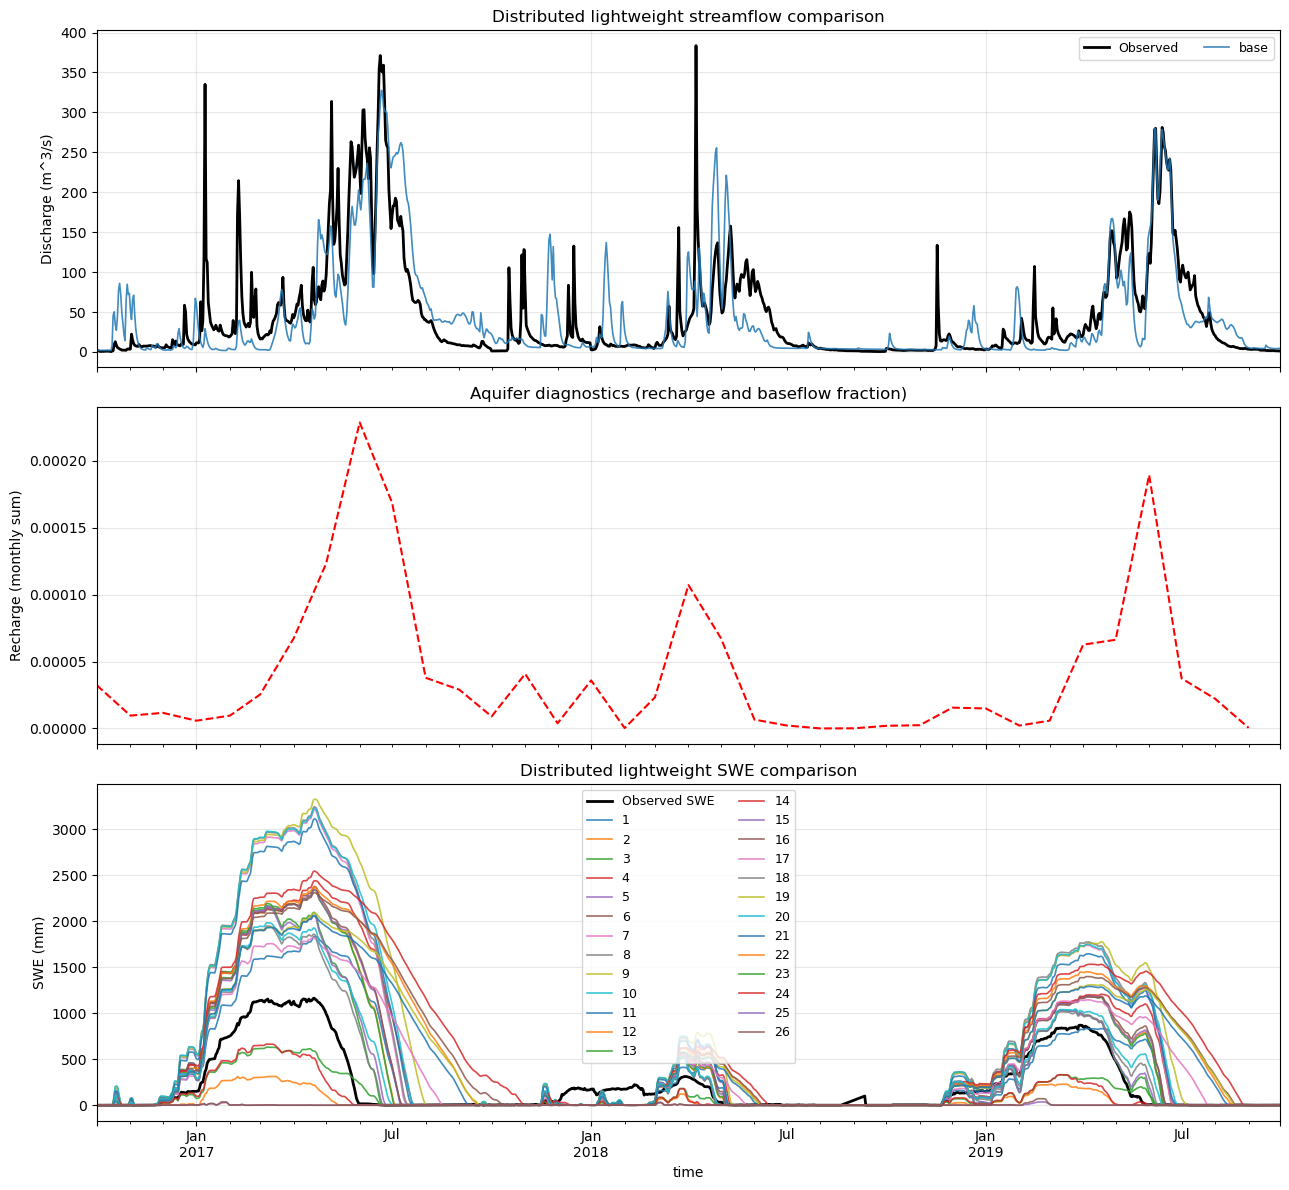

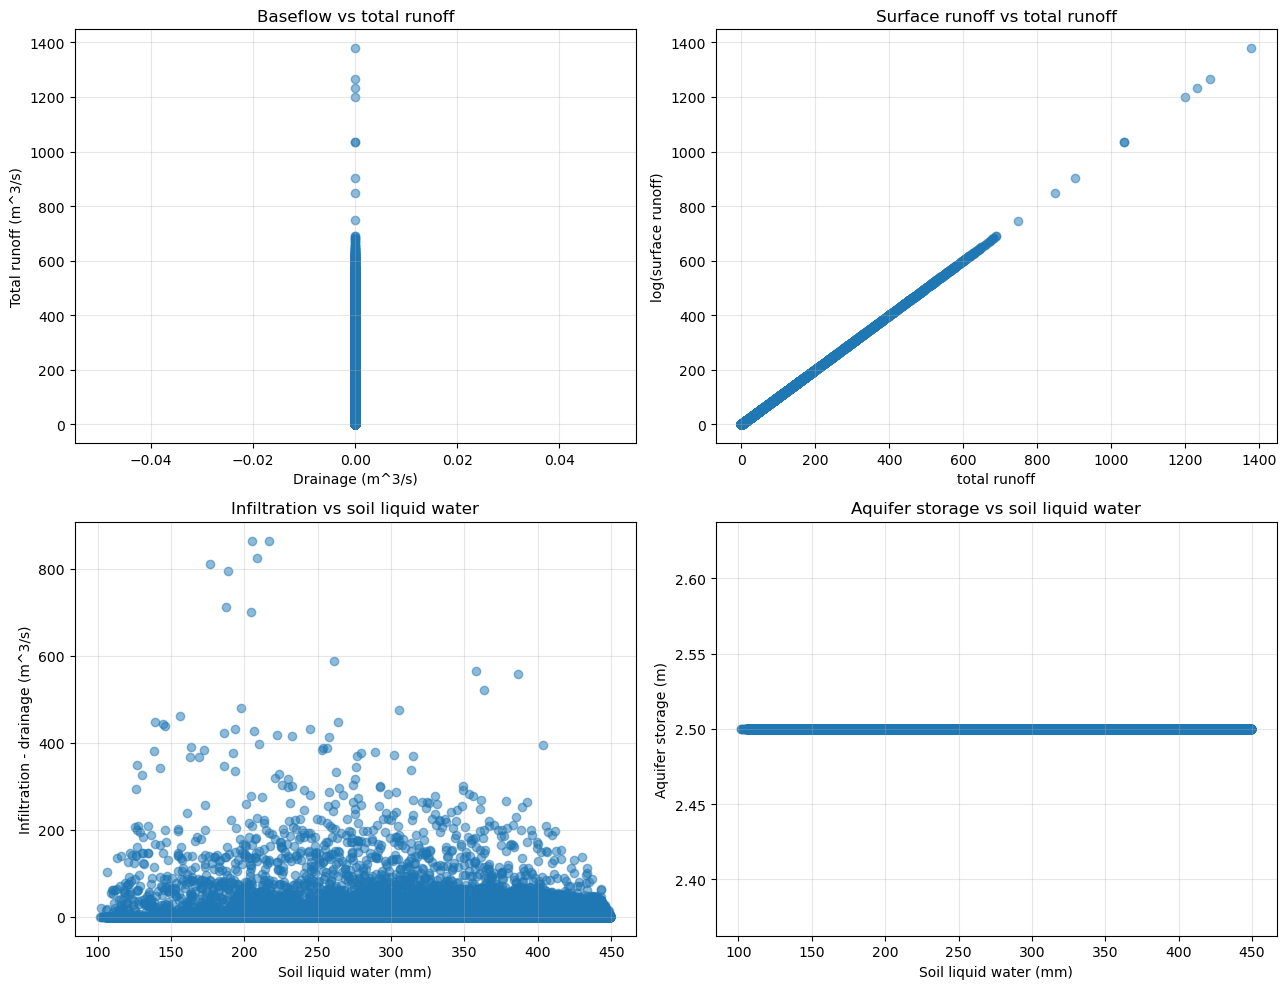

In [43]:
# ---------------------------------------------------------------------
# DETAILED DIAGNOSTICS (lumped-style plots adapted for distributed runs)
# ---------------------------------------------------------------------
if not scenario_outputs:
    print('No successful scenario outputs to plot.')
else:
    timeslice_q = slice(pd.Timestamp(EVAL_START), pd.Timestamp(EVAL_END))
    timeslice_m = slice(pd.Timestamp(EVAL_START).to_period('M').to_timestamp(), pd.Timestamp(EVAL_END).to_period('M').to_timestamp())

    if 'metrics_df' in globals() and not metrics_df.empty:
        selected_scenarios = metrics_df.head(min(4, len(metrics_df)))['scenario'].tolist()
    else:
        selected_scenarios = list(scenario_outputs.keys())[: min(4, len(scenario_outputs))]

    reference_scenario = BASE_SCENARIO_NAME if BASE_SCENARIO_NAME in scenario_outputs else selected_scenarios[0]
    print(f'Selected scenarios: {selected_scenarios}')
    print(f'Reference scenario: {reference_scenario}')

    # Figure 1: streamflow, aquifer diagnostics, SWE
    fig, axes = plt.subplots(3, 1, figsize=(13, 12), sharex=True)

    ax = axes[0]
    if not obs_q.empty:
        obs_q.loc[timeslice_q].plot(ax=ax, color='black', lw=2, label='Observed')
    for scn in selected_scenarios:
        with xr.open_dataset(scenario_outputs[scn]) as ds:
            sim_q, _details = streamflow_series(ds, basin_area_m2, return_details=True)
            sim_q = sim_q.loc[timeslice_q]
            sim_q.plot(ax=ax, lw=1.2, alpha=0.85, label=scn)
    ax.set_title('Distributed lightweight streamflow comparison')
    ax.set_ylabel('Discharge (m^3/s)')
    ax.grid(True, alpha=0.3)
    ax.legend(ncol=2, fontsize=9)

    ax = axes[1]

    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    if 'metrics_df' in globals() and not metrics_df.empty:
        plot_metrics = metrics_df.set_index('scenario')
    else:
        plot_metrics = pd.DataFrame(index=selected_scenarios)

    for ci, scn in enumerate(selected_scenarios):
        color = colors[ci % len(colors)]
        with xr.open_dataset(scenario_outputs[scn]) as ds:
            recharge_var = pick_var(ds, AQ_RECHARGE_CANDIDATES)
            baseflow_var = pick_var(ds, AQ_BASEFLOW_CANDIDATES)
            soil_drainage_var = 'scalarSoilDrainage' if 'scalarSoilDrainage' in ds else None
            surface_runoff_var = 'averageInstantRunoff' if 'averageInstantRunoff' in ds else None
            routed = ds['averageRoutedRunoff'] if 'averageRoutedRunoff' in ds else ds.get('scalarTotalRunoff', None)
            if recharge_var is not None:
                recharge = ds[recharge_var].squeeze().to_pandas().resample('MS').sum().loc[timeslice_m].sum(axis=1)
                if recharge.mean().sum() > 0:
                    ax.plot(recharge.index, recharge.values, lw=1.5, color=color, label=f'{scn} recharge')
                else:
                    # plot soil drainage
                    drainage = ds[soil_drainage_var].squeeze().to_pandas().resample('MS').sum().loc[timeslice_m] if soil_drainage_var else None
                    surface_runoff = ds[surface_runoff_var].squeeze().to_pandas().resample('MS').sum().loc[timeslice_m] if surface_runoff_var else None
                    if recharge.mean().sum()  > 0:
                        ax.plot(drainage.index, drainage.values, lw=1.5, color=color, label=f'{scn} soil drainage')
                    if surface_runoff.mean().sum() > 0:
                        ax.plot(surface_runoff.index, surface_runoff.values, lw=1.5, color='red', linestyle='--', label=f'{scn} surface runoff')
            if baseflow_var is not None and routed is not None:
                baseflow = ds[baseflow_var].sum(dim='hru').squeeze().to_pandas().resample('7D').mean().loc[timeslice_m]
                if baseflow_var != 'basin__ColumnOutflow':
                    baseflow = (baseflow* basin_area_m2)
                if baseflow.mean().sum() > 0:
                    ax2 = ax.twinx()
                    routed_q = routed.squeeze().to_pandas().resample('7D').mean().loc[timeslice_m] * basin_area_m2
                    common = baseflow.index.intersection(routed_q.index)
                    fraction = baseflow.loc[common] / routed_q.loc[common].replace(0, np.nan)
                    ax2.plot(common, fraction.values, lw=1.5, linestyle='--', color=color, label    =f'{scn} baseflow')
                    ax2.set_ylabel('Baseflow fraction')
                    ax2.set_ylim(0, 1)
    ax.set_title('Aquifer diagnostics (recharge and baseflow fraction)')
    ax.set_ylabel('Recharge (monthly sum)')
    # match the x-axis

    ax.grid(True, alpha=0.3)
    lines1, labels1 = ax.get_legend_handles_labels()
    if DECISION_SWEEP['groundwatr'][0] == 'bigBuckt':
        if ax2:
            lines2, labels2 = ax2.get_legend_handles_labels()
        if lines1 or lines2:
            ax.legend(lines1 + lines2, labels1 + labels2, ncol=2, fontsize=9)

    ax = axes[2]
    if not obs_swe.empty:
        obs_swe.loc[timeslice_q].plot(ax=ax, color='black', lw=2, label='Observed SWE')
    for scn in selected_scenarios:
        with xr.open_dataset(scenario_outputs[scn]) as ds:
            sim_swe = swe_daily_mm(ds).loc[timeslice_q]
            sim_swe.plot(ax=ax, lw=1.2, alpha=0.85, label=scn)
    ax.set_title('Distributed lightweight SWE comparison')
    ax.set_ylabel('SWE (mm)')
    ax.grid(True, alpha=0.3)
    ax.legend(ncol=2, fontsize=9)

    plt.tight_layout()
    plt.show()

    # Figure 2: precipitation and temperature comparisons against SNOTEL, if present
    snotel_path = project_dir / 'observations' / 'snow' / SNOTEL_CSV_NAME
    if not snotel_path.exists():
        snotel_path = project_dir / 'observations' / SNOTEL_CSV_NAME

    if snotel_path.exists():
        snotel = pd.read_csv(snotel_path, parse_dates=True, index_col=0)
        precip_col = next((c for c in snotel.columns if 'precip' in c.lower()), None)
        temp_col = next((c for c in snotel.columns if 'air temp' in c.lower() or 'temp' in c.lower()), None)

        with xr.open_dataset(scenario_outputs[reference_scenario]) as ref_ds:
            fig, axes = plt.subplots(1, 2, figsize=(14, 5))

            if precip_col is not None and 'pptrate' in ref_ds:
                obs_precip = (snotel[precip_col].resample('D').mean() * 25.4).loc[timeslice_q]
                model_precip = (ref_ds['pptrate'].sel(time=slice(EVAL_START, EVAL_END)).squeeze() * 3600.0).to_pandas().resample('D').sum()
                axes[0].plot(obs_precip.index, obs_precip.values, color='black', lw=2, label='Observed precip')
                axes[0].plot(model_precip.index, model_precip.values, color='tab:blue', lw=1.2, label='Model precip')
                axes[0].set_title(f'Precipitation comparison: {reference_scenario}')
                axes[0].set_ylabel('mm/day')
                axes[0].grid(True, alpha=0.3)
                axes[0].legend()
            else:
                axes[0].axis('off')
                axes[0].text(0.05, 0.5, 'No SNOTEL precipitation column found', transform=axes[0].transAxes)

            if temp_col is not None and 'airtemp' in ref_ds:
                obs_temp = (((snotel[temp_col].resample('D').mean() - 32.0) * 5.0 / 9.0).loc[timeslice_q])
                model_temp = (ref_ds['airtemp'].sel(time=slice(EVAL_START, EVAL_END)).squeeze() - 273.15).to_pandas().resample('D').mean()
                axes[1].plot(obs_temp.index, obs_temp.values, color='black', lw=2, label='Observed air temp')
                axes[1].plot(model_temp.index, model_temp.values, color='tab:red', lw=1.2, label='Model air temp')
                axes[1].set_title(f'Air temperature comparison: {reference_scenario}')
                axes[1].set_ylabel('degC')
                axes[1].grid(True, alpha=0.3)
                axes[1].legend()
            else:
                axes[1].axis('off')
                axes[1].text(0.05, 0.5, 'No SNOTEL temperature column found', transform=axes[1].transAxes)

            plt.tight_layout()
            plt.show()

    else:
        print(f'WARNING: SNOTEL file not found for precip/temp comparison: {snotel_path}')

    # Figure 3: runoff partitioning and water-storage relationships on reference scenario
    with xr.open_dataset(scenario_outputs[reference_scenario]) as ref_ds:
        fig, axs = plt.subplots(2, 2, figsize=(13, 10))
        axs = axs.flatten()

        routed_runoff = ref_ds['scalarTotalRunoff_mean'] if 'scalarTotalRunoff_mean' in ref_ds else ref_ds.get('scalarTotalRunoff', None)
        baseflow = ref_ds['scalarAquiferBaseflow'] if 'scalarAquiferBaseflow' in ref_ds else None
        surface_runoff = ref_ds['scalarSurfaceRunoff'] if 'scalarSurfaceRunoff' in ref_ds else None
        soil_liq = ref_ds['scalarTotalSoilLiq'] if 'scalarTotalSoilLiq' in ref_ds else None
        infiltration = ref_ds['scalarInfiltration'] if 'scalarInfiltration' in ref_ds else None
        soil_drainage = ref_ds['scalarSoilDrainage'] if 'scalarSoilDrainage' in ref_ds else None
        aquifer_storage = ref_ds['scalarAquiferStorage_mean'] if 'scalarAquiferStorage_mean' in ref_ds else ref_ds.get('scalarAquiferStorage', None)

        if routed_runoff is not None and baseflow is not None:
            routed_series = routed_runoff.squeeze().to_pandas().resample('D').mean().loc[timeslice_q] * basin_area_m2
            baseflow_series = soil_drainage.squeeze().to_pandas().resample('D').mean().loc[timeslice_q] * basin_area_m2
            axs[0].scatter(baseflow_series, routed_series, alpha=0.5)
            axs[0].set_xlabel('Drainage (m^3/s)')
            axs[0].set_ylabel('Total runoff (m^3/s)')
            axs[0].set_title('Baseflow vs total runoff')
            axs[0].grid(True, alpha=0.3)
        else:
            axs[0].axis('off')

        if surface_runoff is not None and routed_runoff is not None:
            surface_series = surface_runoff.squeeze().to_pandas().resample('D').mean().loc[timeslice_q] * basin_area_m2
            routed_series = routed_runoff.squeeze().to_pandas().resample('D').mean().loc[timeslice_q] * basin_area_m2
            axs[1].scatter(routed_series, surface_series, alpha=0.5)
            axs[1].set_xlabel('total runoff')
            axs[1].set_ylabel('log(surface runoff)')
            axs[1].set_title('Surface runoff vs total runoff')
            axs[1].grid(True, alpha=0.3)
        else:
            axs[1].axis('off')

        if infiltration is not None and soil_drainage is not None and soil_liq is not None:
            infiltration_series = (infiltration.squeeze() - soil_drainage.squeeze()).to_pandas().resample('D').mean().loc[timeslice_q] * basin_area_m2
            soil_liq_series = soil_liq.squeeze().to_pandas().resample('D').mean().loc[timeslice_q]
            axs[2].scatter(soil_liq_series, infiltration_series, alpha=0.5)
            axs[2].set_xlabel('Soil liquid water (mm)')
            axs[2].set_ylabel('Infiltration - drainage (m^3/s)')
            axs[2].set_title('Infiltration vs soil liquid water')
            axs[2].grid(True, alpha=0.3)
        else:
            axs[2].axis('off')

        if aquifer_storage is not None and soil_liq is not None:
            aquifer_series = aquifer_storage.squeeze().to_pandas().resample('D').mean().loc[timeslice_q]
            soil_liq_series = soil_liq.squeeze().to_pandas().resample('D').mean().loc[timeslice_q]
            axs[3].scatter(soil_liq_series, aquifer_series, alpha=0.5)
            axs[3].set_xlabel('Soil liquid water (mm)')
            axs[3].set_ylabel('Aquifer storage (m)')
            axs[3].set_title('Aquifer storage vs soil liquid water')
            axs[3].grid(True, alpha=0.3)
        else:
            axs[3].axis('off')

        plt.tight_layout()
        plt.show()

In [45]:
for hru in ds.hru:
    ((-ds['scalarTotalET']-ds['scalarSnowSublimation'])*3600*24*31).sel(hru=hru).groupby('time.month').mean().plot()
# obs_et.groupby(obs_et.index.month).mean().plot()
plt.legend()

FileNotFoundError: [Errno 2] No such file or directory: '/scratch/dlhogan/ess-project-data/domain_Tuolumne_River_distributed_elevAspect/simulations/lightweight_distributed/run_20260427_160711/results/base/SUMMA/light_dist_20260427_160711_base_timestep.nc'

In [44]:
# monthly mean resample
monthly_model_ds = ds['basin__TotalRunoff'].sel(time=timeslice_q).groupby('time.month').mean() * basin_area_m2
monthly_obs_ds = obs_q.loc[timeslice_q].groupby(obs_q.loc[timeslice_q].index.month).mean()

FileNotFoundError: [Errno 2] No such file or directory: '/scratch/dlhogan/ess-project-data/domain_Tuolumne_River_distributed_elevAspect/simulations/lightweight_distributed/run_20260427_160711/results/base/SUMMA/light_dist_20260427_160711_base_timestep.nc'

546.153466923106 551.4516525072812


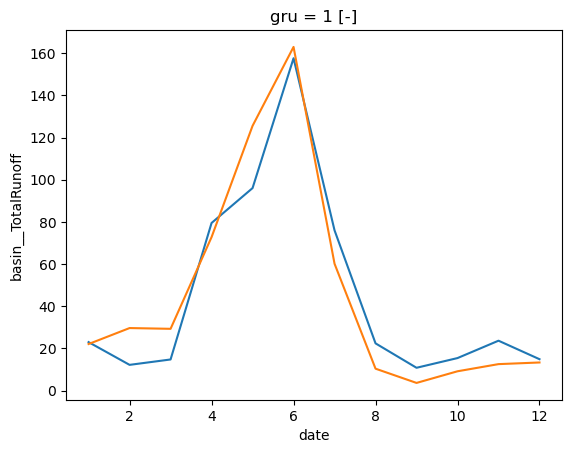

In [ ]:
monthly_model_ds.plot(label='model')
monthly_obs_ds.plot(label='obs')
print(monthly_model_ds.sum().values, monthly_obs_ds.sum())